In [1]:
from mne import SourceEstimate

import helper_functions as hf
import mne
import os.path as op
import numpy as np
from mne_denoise.zapline import ZapLine



In [2]:
#load data

ss = hf.settings_dict()
subject = 1
raw_fname = op.join(ss['raw_dir'], ss['raw_path1_list'][subject])

raw = mne.io.read_raw_fif(raw_fname, preload=True)



Opening raw data file /home/elias/Documents/masters/Thesis/iliasgdk_thesis/raw/0002/20180522_000000/MEG/001.s2/files/s2.fif...
    Read a total of 13 projection items:
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
        generated with autossp-1.2.0 (1 x 306)  idle
    Range : 93000 ... 1274999 =     46.500 ...   637.500 secs
Ready.
Reading 0 ... 1181999  =      0.000 ...   591.000 secs...


/tmp/ipykernel_53930/3628438369.py:7: RuntimeWarning: This filename (/home/elias/Documents/masters/Thesis/iliasgdk_thesis/raw/0002/20180522_000000/MEG/001.s2/files/s2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(raw_fname, preload=True)


In [3]:
print(raw.info)

<Info | 24 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: []
 ch_names: EMG001, EMG002, EOG003, EOG004, EMG005, IASX+, IASX-, IASY+, ...
 chs: 3 EMG, 2 EOG, 11 Internal Active Shielding data (Triux systems), 102 Magnetometers, 204 Gradiometers, 1 misc, 1 Stimulus, 1 System status channel information (Triux systems)
 custom_ref_applied: False
 description: TRIUX system at Aarhus
 dev_head_t: MEG device -> head transform
 dig: 139 items (3 Cardinal, 4 HPI, 132 Extra)
 events: 1 item (list)
 experimenter: Marie Louise Holm Moller (marielouise)
 file_id: 4 items (dict)
 gantry_angle: 68.0
 highpass: 0.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 3 items (dict)
 line_freq: 50.0
 lowpass: 650.0 Hz
 meas_date: 2018-05-22 10:47:18 UTC
 meas_id: 4 items (dict)
 nchan: 325
 proj_id: 52
 proj_name: flicker
 projs: generated with autossp-1.2.0: off, generated with autossp-1.2.0: ...
 sfreq: 2000.0 Hz
 subject_info:

Using matplotlib as 2D backend.


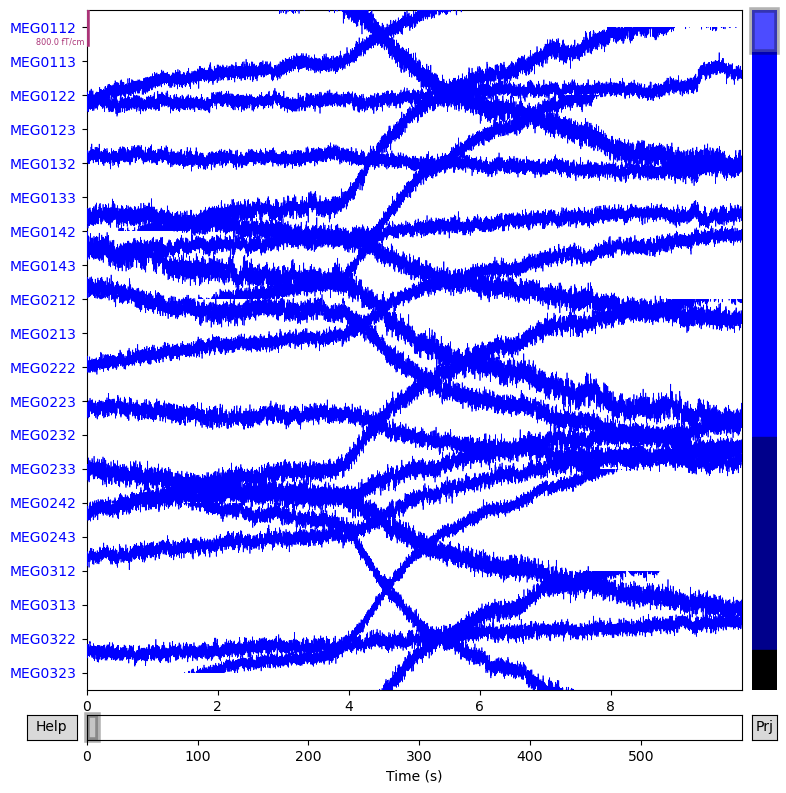

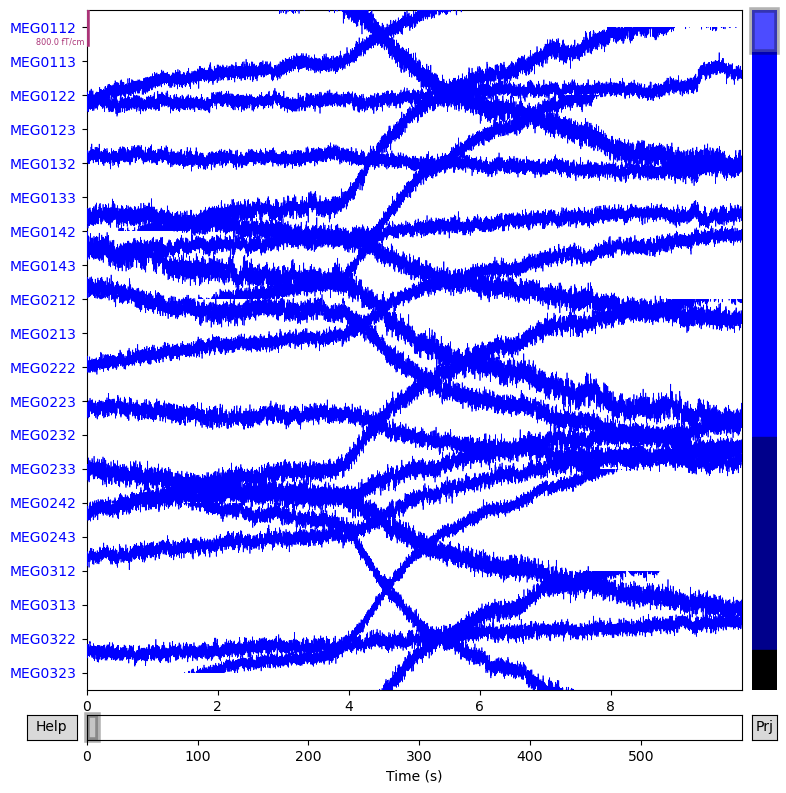

In [4]:
#inspect for bad channels
# %matplotlib qt
raw.plot(block=True)

In [5]:
#exclude bad channels (MEG1143)
raw_filtered = raw.copy() #.crop(tmin=0, tmax=160.5)
raw_filtered.info['bads'] = ss['bads']
raw_filtered.pick(picks=['grad', 'stim'])


del(raw)
#this was done in the original pre-processing
# raw.set_channel_types(mapping={'EMG001': 'eeg'})
# raw.set_channel_types(mapping={'EMG002': 'eeg'})
# raw.set_channel_types(mapping={'EOG003': 'eeg'})
# raw.set_channel_types(mapping={'EOG004': 'eeg'})
# raw.set_channel_types(mapping={'EMG005': 'eeg'})
# raw.set_channel_types(mapping={'MISC001': 'eeg'})

Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/home/elias/miniconda3/envs/iliasgdk_thesis/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


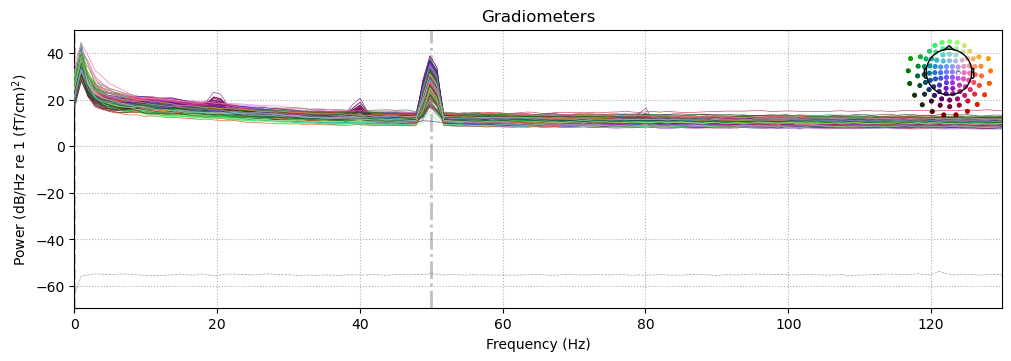

In [6]:
#plot signal power for each frequency
raw_filtered.compute_psd(fmax=130).plot()

In [7]:
#line noise removal
raw_filtered.notch_filter(freqs=[50], method='spectrum_fit')

Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     50.00 : 23868 windows


<Raw | s2.fif, 205 x 1182000 (591.0 s), ~1.81 GiB, data loaded>

Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/home/elias/miniconda3/envs/iliasgdk_thesis/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


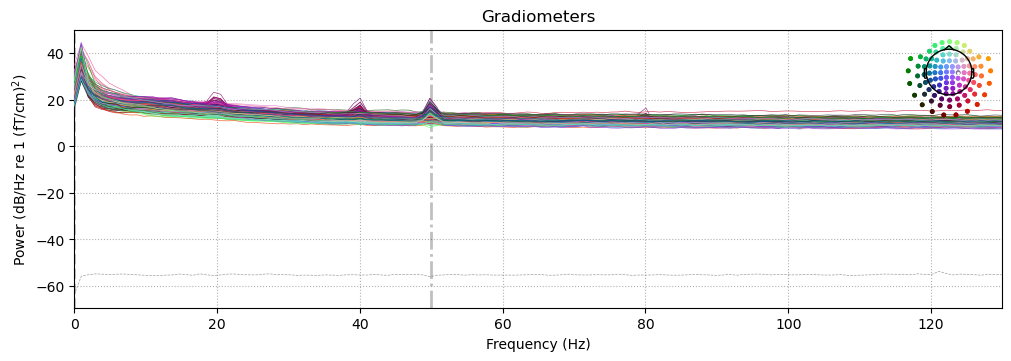

In [8]:
#plot signal power for each frequency
raw_filtered.compute_psd(fmax=130).plot()

In [9]:
#filter 35 - 45 Hz


raw_filtered.filter(l_freq=35,h_freq=45)

print(raw_filtered.info)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 35 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 35.00
- Lower transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 30.62 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 755 samples (0.378 s)

<Info | 25 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: 1 items (MEG1143)
 ch_names: MEG0112, MEG0113, MEG0122, MEG0123, MEG0132, MEG0133, MEG0142, ...
 chs: 204 Gradiometers, 1 Stimulus
 custom_ref_applied: False
 description: TRIUX system at Aarhus
 dev_head_t: MEG device -> head transform
 dig: 139 items (3 Cardinal, 4 HPI, 132 Extra)
 events: 1 item (list)
 experimenter: M

Effective window size : 1.024 (s)
Plotting power spectral density (dB=True).


/home/elias/miniconda3/envs/iliasgdk_thesis/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


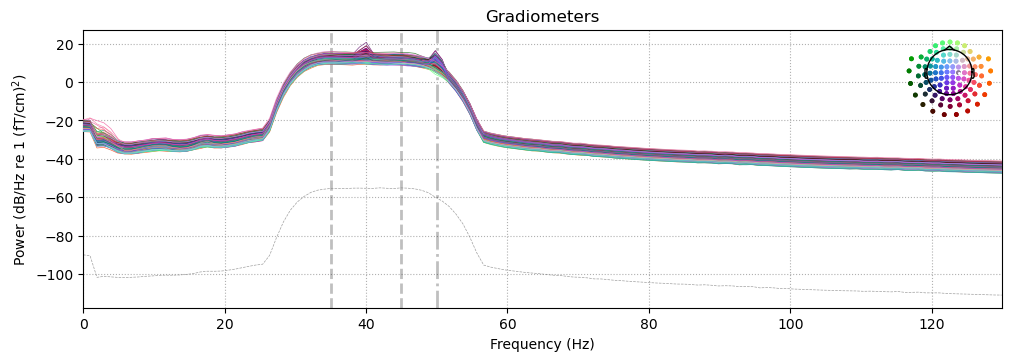

In [10]:
#plot signal power for each frequency
raw_filtered.compute_psd(fmax=130).plot()

In [11]:
#cut data into epochs
tmin = -0.5
tmax = 4.5

events = mne.find_events(raw_filtered)
event_id_list =  ss['event_id_list']

epochs = mne.Epochs(raw_filtered, events, event_id_list, tmin=tmin, tmax=tmax, preload=True)

del(raw_filtered)



Finding events on: STI101
70 events found on stim channel STI101
Event IDs: [1 2 3 4 5 6 7]
Not setting metadata
70 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 5)
13 projection items activated
Using data from preloaded Raw for 70 events and 10001 original time points ...


/tmp/ipykernel_53930/508792309.py:8: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  epochs = mne.Epochs(raw_filtered, events, event_id_list, tmin=tmin, tmax=tmax, preload=True)


0 bad epochs dropped


In [12]:
#check that all trials are present
print(epochs.get_data().shape)
print(epochs.info)

(70, 205, 10001)
<Info | 25 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: 1 items (MEG1143)
 ch_names: MEG0112, MEG0113, MEG0122, MEG0123, MEG0132, MEG0133, MEG0142, ...
 chs: 204 Gradiometers, 1 Stimulus
 custom_ref_applied: False
 description: TRIUX system at Aarhus
 dev_head_t: MEG device -> head transform
 dig: 139 items (3 Cardinal, 4 HPI, 132 Extra)
 events: 1 item (list)
 experimenter: Marie Louise Holm Moller (marielouise)
 file_id: 4 items (dict)
 gantry_angle: 68.0
 highpass: 35.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 3 items (dict)
 line_freq: 50.0
 lowpass: 45.0 Hz
 meas_date: 2018-05-22 10:47:18 UTC
 meas_id: 4 items (dict)
 nchan: 205
 proj_id: 52
 proj_name: flicker
 projs: generated with autossp-1.2.0: on, generated with autossp-1.2.0: ...
 sfreq: 2000.0 Hz
 subject_info: <subject_info | id: 1641, last_name: 0002, first_name: TCZ, birthday: 1978-09-13, sex: 1, hand: 1>
>


/home/elias/miniconda3/envs/iliasgdk_thesis/lib/python3.13/site-packages/matplotlib_inline/backend_inline.py:26: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  return new_figure_manager_given_figure(num, FigureClass(*args, **kwargs))


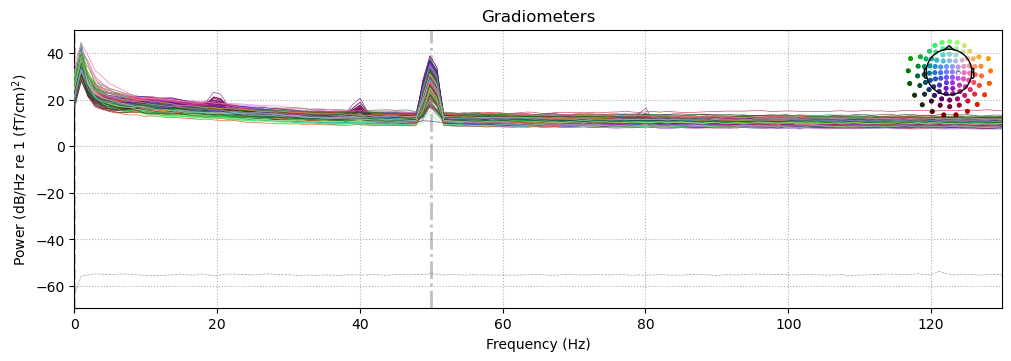

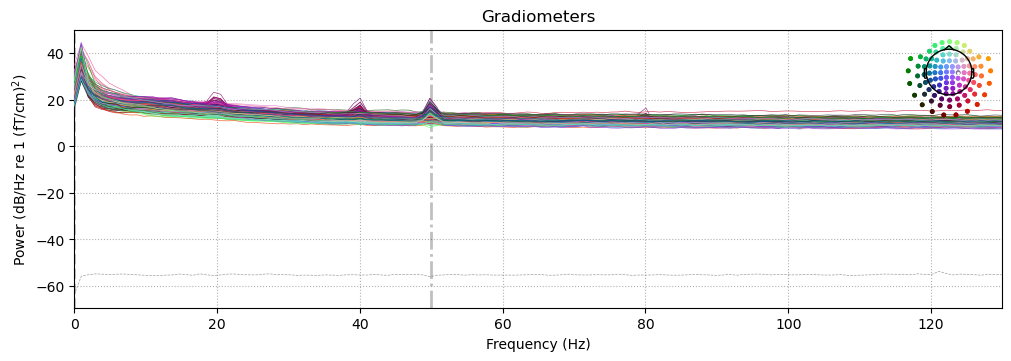

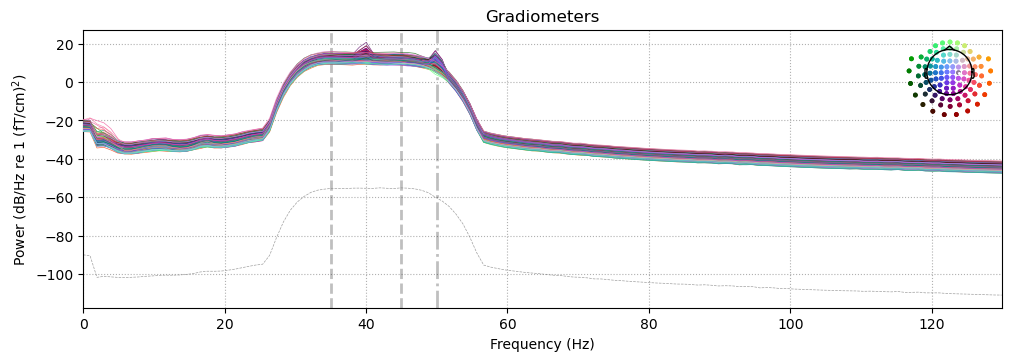

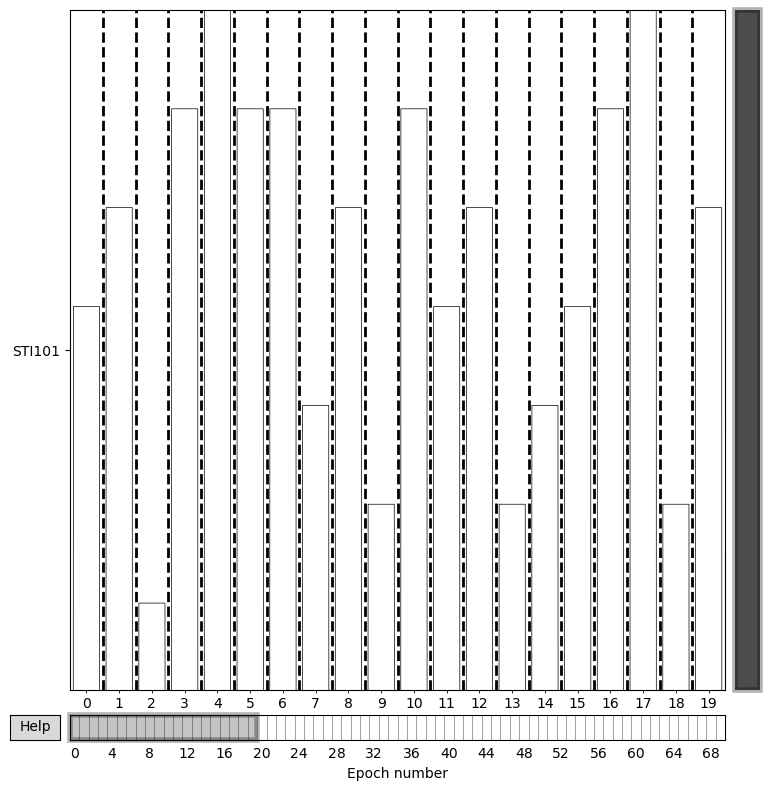

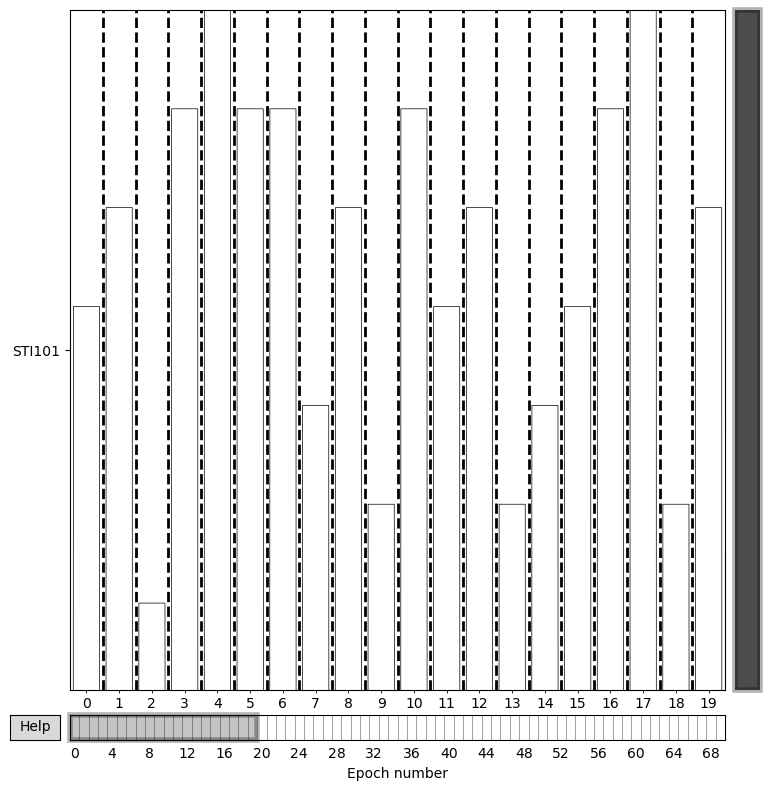

In [13]:
epochs.plot(picks='stim')

In [14]:
#average
evokeds = {}

for event_id in event_id_list:
    evokeds[event_id] = epochs[event_id].average()


In [16]:
from mne.beamformer import make_lcmv, apply_lcmv_epochs

#Source localization
evoked = evokeds[1]
evoked.pick('grad')

data_cov = mne.compute_covariance(epochs, tmin=0.01, tmax=tmax)

filter = make_lcmv(
    evoked.info,
    fwd,
    data_cov=data_cov,
    reg=0.05,
    pick_ori='max-power',
    weight_norm='nai'
)


stcs = apply_lcmv_epochs(evoked, filter)

/tmp/ipykernel_53930/1028569147.py:7: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  data_cov = mne.compute_covariance(epochs, tmin=0.01, tmax=tmax)


    Created an SSP operator (subspace dimension = 5)
    Setting small GRAD eigenvalues to zero (without PCA)


/tmp/ipykernel_53930/1028569147.py:7: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  data_cov = mne.compute_covariance(epochs, tmin=0.01, tmax=tmax)


Reducing data rank from 203 -> 198
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 628670
[done]
Computing rank from covariance with rank='info'
    GRAD: rank 198 after 5 projectors applied to 203 channels
Computing rank from covariance with rank='info'
    GRAD: rank 198 after 5 projectors applied to 203 channels
Making LCMV beamformer with rank {'grad': 198}
Computing inverse operator with 203 channels.
    203 out of 306 channels remain after picking
Selected 203 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 5)
Computing rank from covariance with rank={'grad': 198}


/tmp/ipykernel_53930/1028569147.py:9: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  filter = make_lcmv(
/tmp/ipykernel_53930/1028569147.py:9: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_ra

    Setting small GRAD eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.


/tmp/ipykernel_53930/1028569147.py:9: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  filter = make_lcmv(
/tmp/ipykernel_53930/1028569147.py:9: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_ra

Computing beamformer filters for 1868 sources
Filter computation complete
[done]


/tmp/ipykernel_53930/1028569147.py:19: RuntimeWarning: Projection vector 'generated with autossp-1.2.0' has been reduced to 23.36% of its original magnitude by subselecting 203/204 of the original channels. If the ignored channels were bad during SSP computation, we recommend recomputing proj (via compute_proj_raw or related functions) with the bad channels properly marked, because computing SSP with bad channels present in the data but unmarked is dangerous (it can bias the PCA used by SSP). On the other hand, if you know that all channels were good during SSP computation, you can safely use info.normalize_proj() to suppress this warning during projection.
  stcs = apply_lcmv_epochs(evoked, filter)


In [15]:
#Load forward model (later I should probably make it from scratch)
fwd_fname = op.join(ss['fwd_dir'], '0002_TCZ-fwd.fif')
fwd = mne.read_forward_solution(fwd_fname)


Reading forward solution from /home/elias/Documents/masters/Thesis/iliasgdk_thesis/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


In [17]:
stc = stcs[0].copy()
del stcs


Showing: t = 1.309 s, (29.1, -60.0, 29.6) mm, [11, 4, 9] vox, 3485 vertex
Using control points [3.94107276 4.32567957 7.22388893]


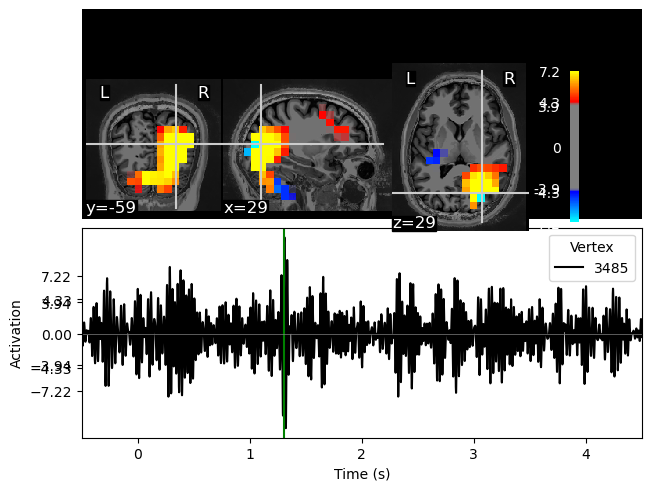

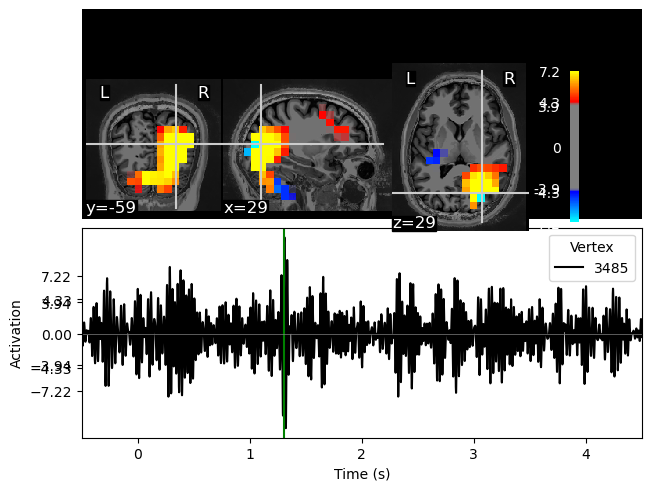

In [18]:
subject = "fs_0002_TCZ"            # or your subject ID
subjects_dir = "/home/elias/Documents/masters/Thesis/iliasgdk_thesis/scratch/fs_subjects_dir"

stc.copy().plot(src= fwd['src'],subject=subject,subjects_dir=subjects_dir)

In [ ]:
#apply hilbert transform
from scipy.signal import hilbert

analytic = hilbert(stc.data, axis=1)
envelope = np.abs(analytic)       # amplitude envelope
stc_power = stc.copy()
stc_power._data = envelope


In [ ]:
# =========================
# AVERAGE POWER OVER STEADY WINDOW
# =========================
trial_power = []

for stc in power_stcs:
    stc_crop = stc.copy().crop(tmin=0.5, tmax=4.0)
    trial_power.append(stc_crop.data.mean(axis=1))

mean_power = np.mean(trial_power, axis=0)
stc_mean = power_stcs[0].copy()
stc_mean._data = mean_power[:, np.newaxis]

# =========================
# BASELINE CONTRAST
# =========================
stc_example = power_stcs[0]

baseline = stc_example.copy().crop(tmin=-1, tmax=0)
active = stc_example.copy().crop(tmin=0.5, tmax=4)

baseline_power = baseline.data.mean(axis=1)
active_power = active.data.mean(axis=1)
relative = active_power / baseline_power

stc_contrast = stc_example.copy()
stc_contrast._data = relative[:, np.newaxis]

# =========================
# PLOT MEAN 40 Hz POWER
# =========================
print("Plotting mean 40 Hz source power...")
brain = stc_mean.plot(
    subject=subject,
    subjects_dir=subjects_dir,
    hemi="both",
    time_label="40 Hz Power",
    clim="auto"
)

# =========================
# PLOT BASELINE CONTRAST
# =========================
print("Plotting baseline contrast (active / baseline)...")
brain2 = stc_contrast.plot(
    subject=subject,
    subjects_dir=subjects_dir,
    hemi="both",
    time_label="Relative 40 Hz Power",
    clim="auto"
)